# Explanation — Email/Outbound Luggage Offer

Applies three explanation methods to the CatBoost surrogate trained in notebook 04:
- **§9 Decision Tree surrogate** — global, interpretable proxy fitted fitted directly to Pega
  propensity scores
- **§10 SHAP** — global feature attributions via TreeExplainer
- **§11 LIME** — local linear explanations aggregated to global importances

Artifacts are saved to `data/artifacts/{VARIANT}/` for notebooks 06–07.

**Run `04_surrogate.ipynb` first.**

In [1]:
# ── Config ────────────────────────────────────────────────────────────────
from pathlib import Path
from my_project.parsing import THIRDPARTY_VARIANTS

VARIANT       = "Cartrawler"
PROCESSED_DIR = Path("../data/processed")
ARTIFACT_DIR  = Path("../data/artifacts") / VARIANT

PROCESSED_FILE = PROCESSED_DIR / (
    "thirdparty_email_outbound.parquet" if VARIANT in THIRDPARTY_VARIANTS
    else "luggage_email_outbound.parquet"
)
print(f"Variant  : {VARIANT}")
print(f"Input    : {PROCESSED_FILE}")
print(f"Artifacts: {ARTIFACT_DIR}")

Variant  : Cartrawler
Input    : ..\data\processed\thirdparty_email_outbound.parquet
Artifacts: ..\data\artifacts\Cartrawler


In [2]:
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
from catboost import CatBoostRegressor
from sklearn.tree import plot_tree

sys.path.insert(0, "../src")
from my_project.explanation import (
    PegaBinEncoder,
    aggregate_lime_importances,
    annotate_dt_rules,
    dt_importances,
    dt_rules,
    dt_surrogate,
    lime_explain_batch,
    shap_importances,
)
from my_project.features import PEGA_MODEL_IDS, VARIANT_FEATURES
from my_project.metrics import feature_ranking, jaccard_at_k, stability_spearman
from my_project.parsing import load_pega_bins
from my_project.surrogate import build_feature_matrix

print("Imports OK")

Imports OK


In [3]:
# ── Load data and artifacts saved by notebook 04 ──────────────────────────
df = pd.read_parquet(PROCESSED_FILE)
df = df[df["pyName"] == VARIANT].reset_index(drop=True)

cfg = VARIANT_FEATURES[VARIANT]
X, y, cat_cols, num_cols = build_feature_matrix(df, list(cfg.features), cfg.numeric)

train_idx = np.load(ARTIFACT_DIR / "train_idx.npy")
test_idx  = np.load(ARTIFACT_DIR / "test_idx.npy")
X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
X_test,  y_test  = X.iloc[test_idx],  y.iloc[test_idx]

cb_model = CatBoostRegressor()
cb_model.load_model(str(ARTIFACT_DIR / "catboost_model.cbm"))

print(f"Rows total: {len(df):,}  |  Train: {len(X_train):,}  |  Test: {len(X_test):,}")
print(f"Features  : {X.shape[1]}  ({len(num_cols)} numeric, {len(cat_cols)} categorical)")
print("CatBoost model loaded.")

Rows total: 42,160  |  Train: 33,728  |  Test: 8,432
Features  : 25  (10 numeric, 15 categorical)
CatBoost model loaded.


## 9. Decision Tree Surrogate

A shallow Decision Tree is fitted directly on the logged Pega propensity scores $\hat{p}$, providing a single-layer global approximation of the black-box model without an intermediate surrogate.  
The tree serves as a fully transparent global proxy: its split rules can be read verbatim as business rules.  
Depth is selected by 5-fold CV on Spearman ρ between tree predictions and $\hat{p}$.

In [4]:
### 9.1  Fit Decision Tree (CV depth selection on Pega propensity scores)
# DT is fitted directly on logged Pega propensity scores y_train (not CatBoost predictions),
# introducing only one layer of approximation error instead of two.

# Build a PegaBinEncoder so DT splits use Pega's learned category groupings
# instead of arbitrary alphabetical ordinal codes.
# load_pega_bins reads the 265 MB binning snapshot — takes ~10 s.
print("Loading Pega bins (this takes ~10 s)...")
_model_id = PEGA_MODEL_IDS[VARIANT]
pega_bins  = load_pega_bins("../data/adm/data-Predictor-binning-snapshot.json", _model_id)
pega_enc   = PegaBinEncoder(pega_bins, cat_cols)

print(f"Pega bins loaded for {len(pega_bins)} predictors")
print(f"Coverage: {sum(1 for c in cat_cols if c.replace('param::', '') in pega_bins)} / {len(cat_cols)} cat features have Pega bins")

dt, best_depth, dt_cv_df, dt_encoder = dt_surrogate(
    X_train, y_train, cat_cols, num_cols,
    max_depth_range=range(1, 9),
    n_splits=5,
    encoder=pega_enc,
)

display(
    dt_cv_df.style
    .format("{:.4f}")
    .highlight_max(subset=["mean_rho"], color="#d4edda")
)
print(f"\nSelected depth: {best_depth}")

Loading Pega bins (this takes ~10 s)...
Pega bins loaded for 25 predictors
Coverage: 2 / 15 cat features have Pega bins


,mean_rho,std_rho
depth,,
1,-0.0530,0.0115
2,0.1051,0.0257
3,0.2470,0.0164
4,0.3120,0.0121
5,0.3707,0.0212
6,0.3889,0.0194
7,0.4162,0.0176
8,0.4231,0.0179



Selected depth: 8


In [5]:
### 9.2  DT fidelity (vs Pega propensity scores on test set)
from my_project.metrics import fidelity_suite
from my_project.explanation import _encode_for_sklearn

X_test_enc, _ = _encode_for_sklearn(X_test, cat_cols, encoder=dt_encoder, fit=False)
dt_pred_test  = dt.predict(X_test_enc)

fid = fidelity_suite(y_test.values, dt_pred_test)
print("Decision Tree fidelity (vs Pega propensity scores on test set):")
print(pd.Series(fid).drop("model", errors="ignore").to_string())

Decision Tree fidelity (vs Pega propensity scores on test set):
r2              0.057700
rmse            0.001344
spearman_rho    0.451700
kendall_tau     0.317000
ks_stat         0.287000


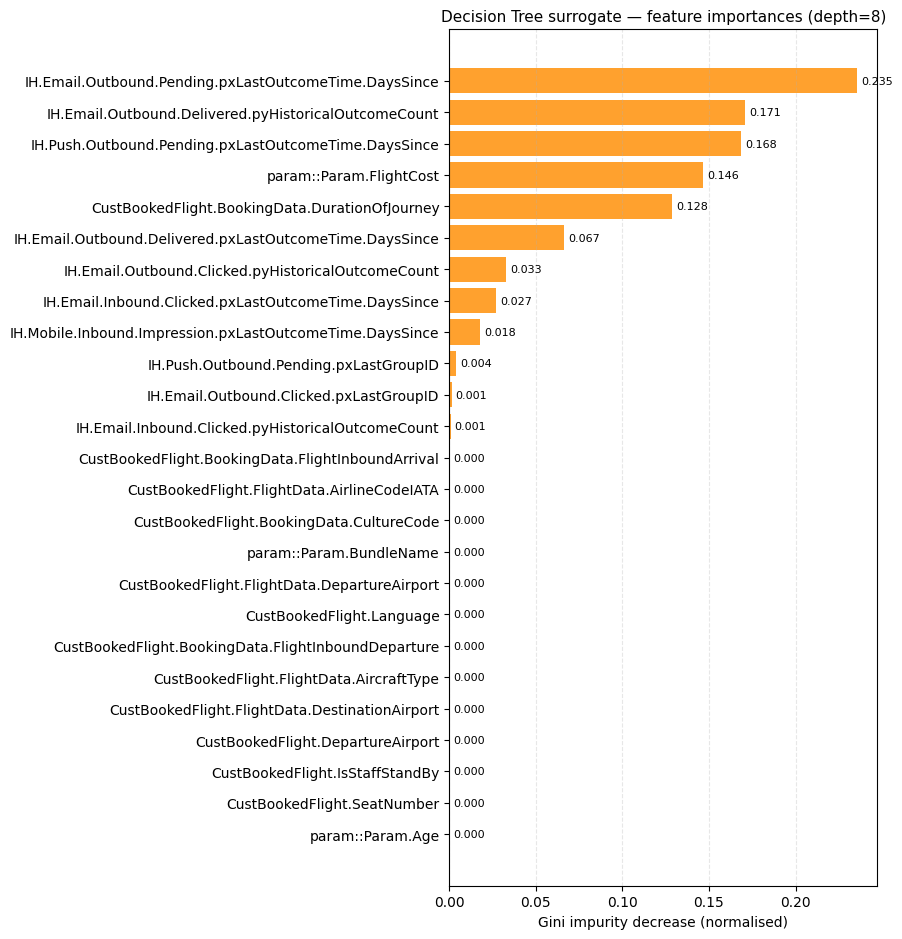

,importance,rank
IH.Email.Outbound.Pending.pxLastOutcomeTime.DaysSince,0.2355,1
IH.Email.Outbound.Delivered.pyHistoricalOutcomeCount,0.1708,2
IH.Push.Outbound.Pending.pxLastOutcomeTime.DaysSince,0.1684,3
param::Param.FlightCost,0.1465,4
CustBookedFlight.BookingData.DurationOfJourney,0.1285,5
IH.Email.Outbound.Delivered.pxLastOutcomeTime.DaysSince,0.0666,6
IH.Email.Outbound.Clicked.pyHistoricalOutcomeCount,0.0330,7
IH.Email.Inbound.Clicked.pxLastOutcomeTime.DaysSince,0.0271,8
IH.Mobile.Inbound.Impression.pxLastOutcomeTime.DaysSince,0.0179,9
IH.Push.Outbound.Pending.pxLastGroupID,0.0038,10


In [6]:
### 9.3  DT feature importances
dt_imp = dt_importances(dt, list(X_train.columns))
dt_ranks = feature_ranking(dt_imp)

fig, ax = plt.subplots(figsize=(9, max(4, len(dt_imp) * 0.38)))
bars = ax.barh(dt_imp.index[::-1], dt_imp.values[::-1], color="darkorange", alpha=0.82)
ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=8)
ax.set_xlabel("Gini impurity decrease (normalised)")
ax.set_title(f"Decision Tree surrogate — feature importances (depth={best_depth})", fontsize=11)
ax.grid(axis="x", alpha=0.3, linestyle="--")
plt.tight_layout()
plt.show()

display(
    pd.DataFrame({"importance": dt_imp, "rank": dt_ranks})
    .style.format({"importance": "{:.4f}", "rank": "{:d}"})
)

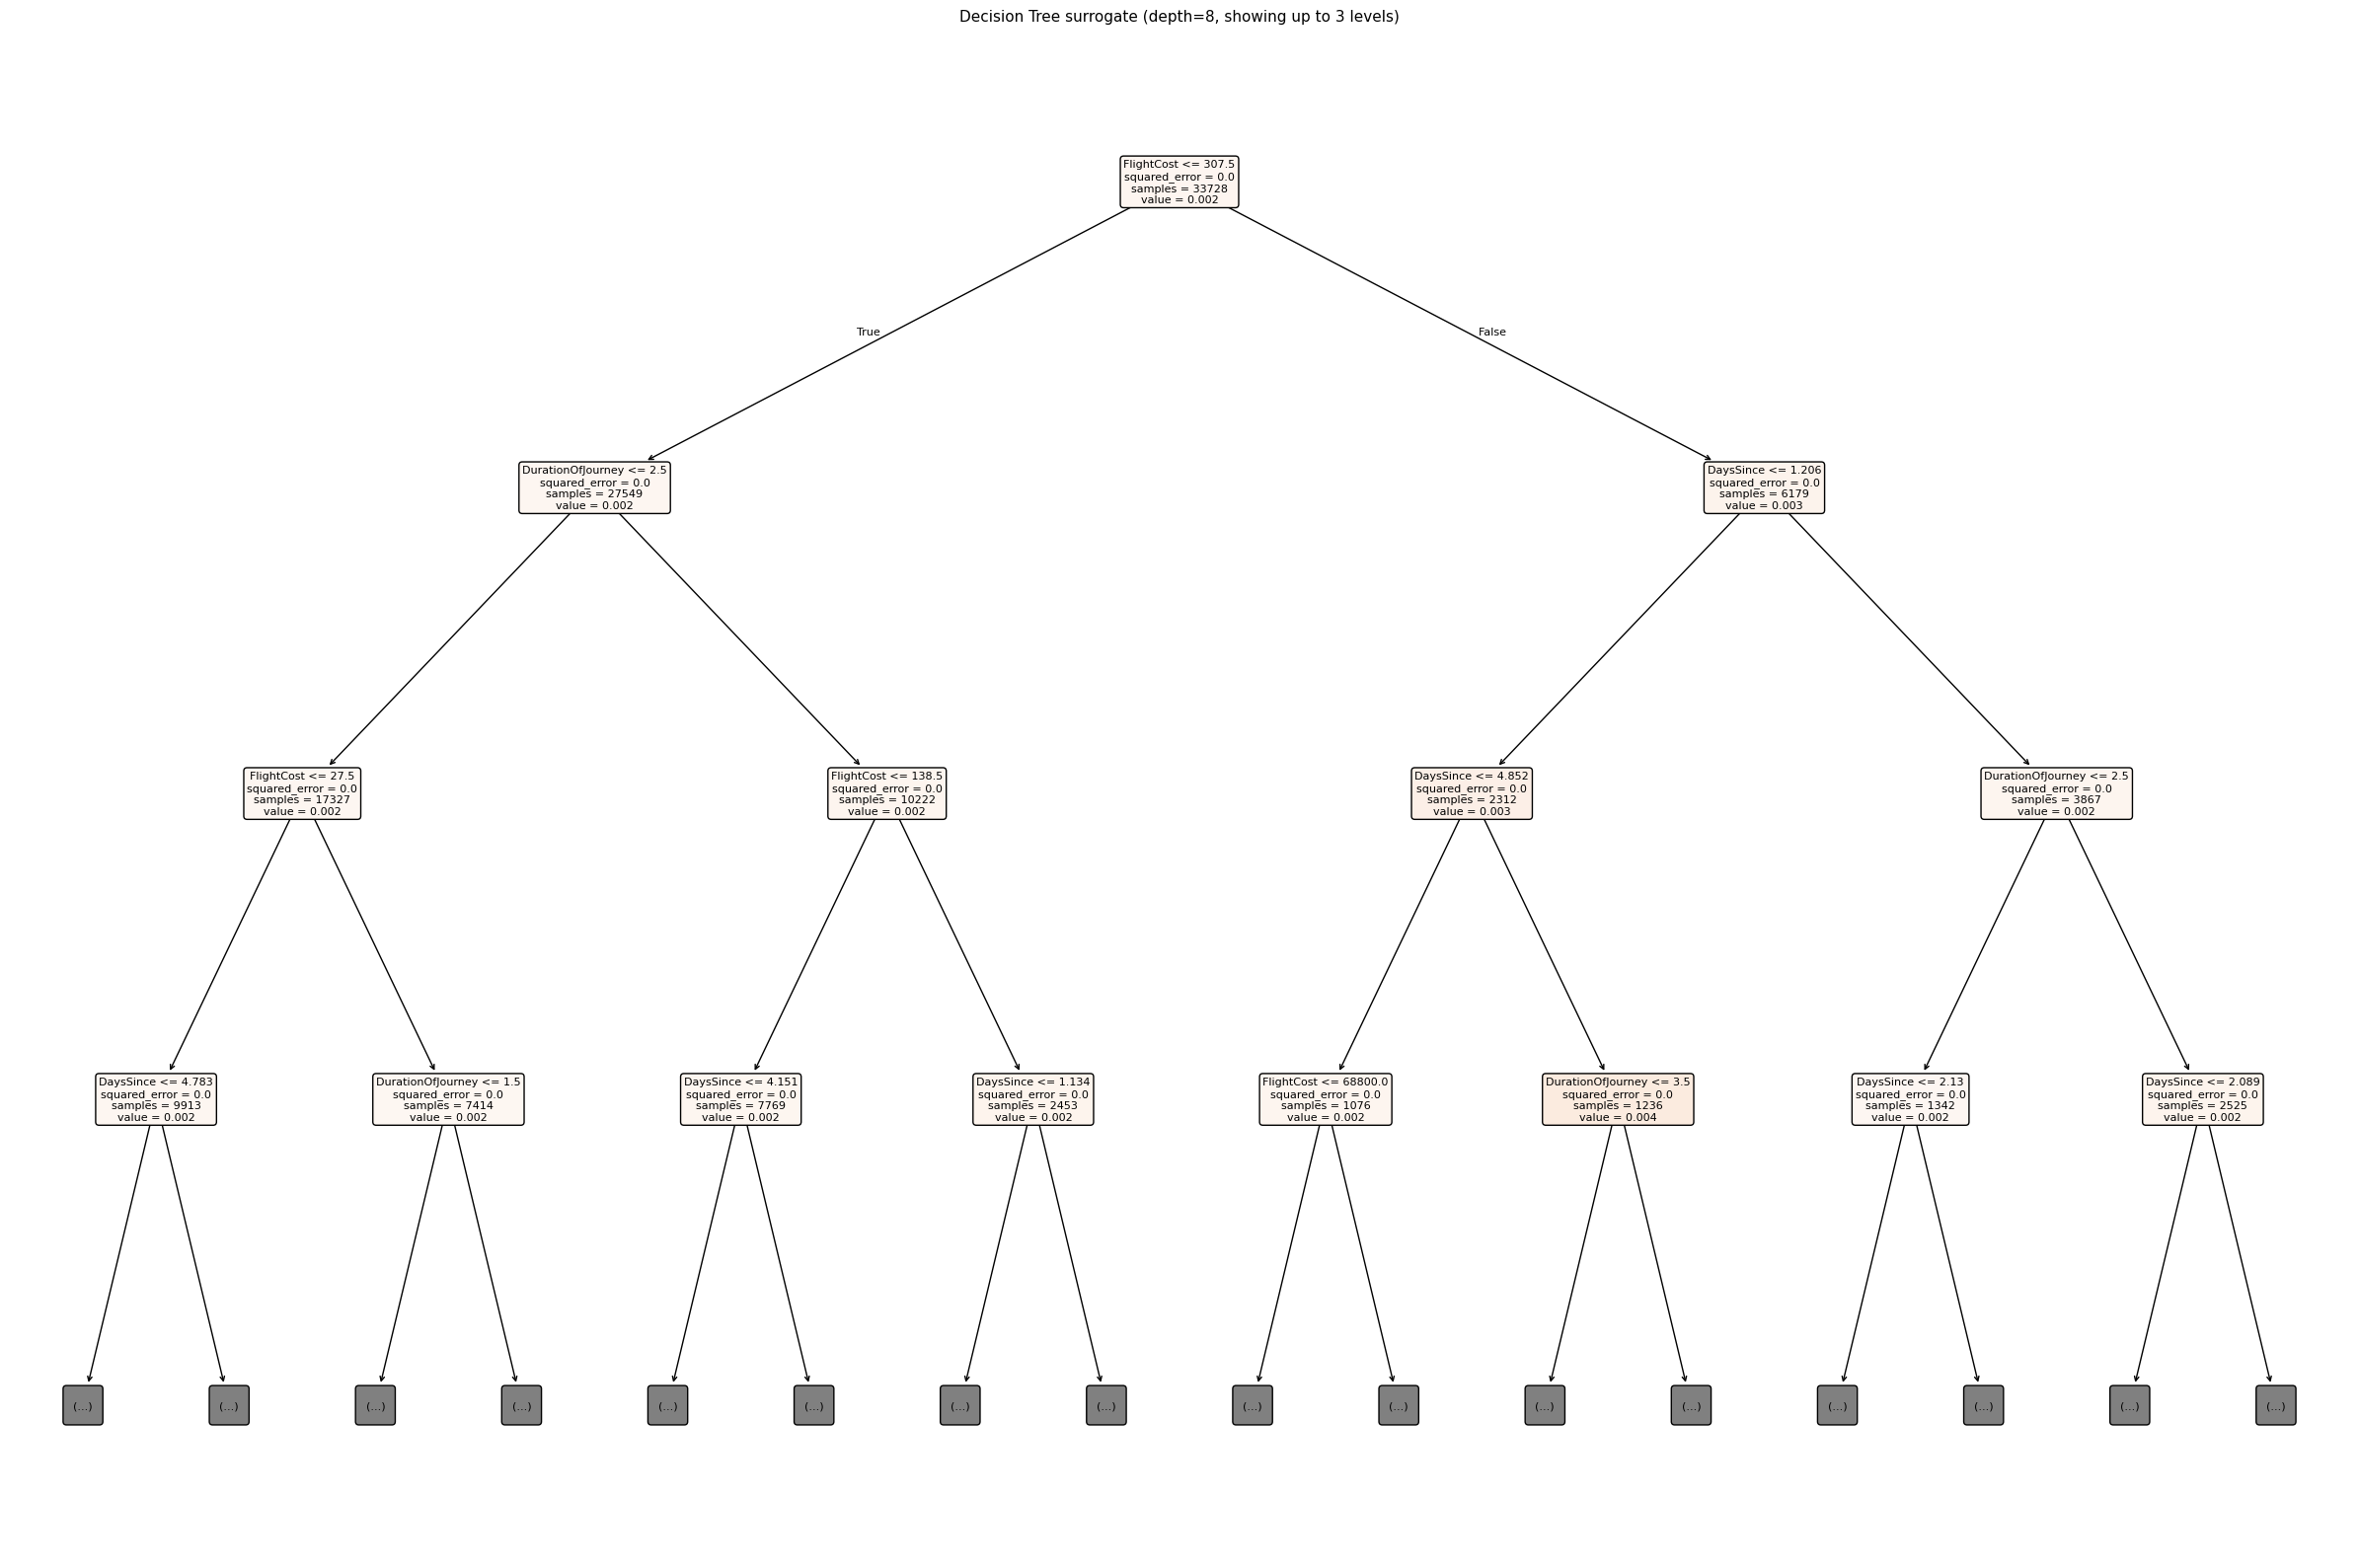

In [7]:
### 9.4  Tree visualisation
# Depth capped at 3 for readability; full rules printed below.
SHORT_NAMES = {col: col.split(".")[-1] for col in X_train.columns}
short_feature_names = [SHORT_NAMES.get(c, c) for c in X_train.columns]

fig, ax = plt.subplots(figsize=(max(14, best_depth * 3), max(6, best_depth * 2)))
plot_tree(
    dt,
    feature_names=short_feature_names,
    filled=True,
    rounded=True,
    max_depth=min(3, best_depth),
    ax=ax,
    fontsize=8,
)
ax.set_title(f"Decision Tree surrogate (depth={best_depth}, showing up to 3 levels)", fontsize=11)
plt.tight_layout()
plt.show()

In [8]:
### 9.5  Decision rules (text)
# annotate_dt_rules replaces ordinal codes with actual category values so that
# splits like 'BundleName <= 5.50' become 'BundleName in {BUNDLE_A, BUNDLE_B, ...}'.
rules_text = dt_rules(dt, list(X_train.columns), max_depth=best_depth)
rules_annotated = annotate_dt_rules(rules_text, cat_cols, dt_encoder)
print(rules_annotated[:3000])  # truncate for display; full text saved to file

(ARTIFACT_DIR / "dt_rules.txt").write_text(rules_annotated, encoding="utf-8")
print(f"\n(Full rules saved to {ARTIFACT_DIR / 'dt_rules.txt'})")

|--- param::Param.FlightCost <= 307.50
|   |--- CustBookedFlight.BookingData.DurationOfJourney <= 2.50
|   |   |--- param::Param.FlightCost <= 27.50
|   |   |   |--- IH.Email.Outbound.Pending.pxLastOutcomeTime.DaysSince <= 4.78
|   |   |   |   |--- IH.Email.Outbound.Pending.pxLastOutcomeTime.DaysSince <= 3.25
|   |   |   |   |   |--- param::Param.FlightCost <= 26.50
|   |   |   |   |   |   |--- IH.Push.Outbound.Pending.pxLastOutcomeTime.DaysSince <= 0.83
|   |   |   |   |   |   |   |--- IH.Push.Outbound.Pending.pxLastOutcomeTime.DaysSince <= 0.39
|   |   |   |   |   |   |   |   |--- value: [0.00]
|   |   |   |   |   |   |   |--- IH.Push.Outbound.Pending.pxLastOutcomeTime.DaysSince >  0.39
|   |   |   |   |   |   |   |   |--- value: [0.00]
|   |   |   |   |   |   |--- IH.Push.Outbound.Pending.pxLastOutcomeTime.DaysSince >  0.83
|   |   |   |   |   |   |   |--- IH.Email.Outbound.Delivered.pyHistoricalOutcomeCount <= 10.50
|   |   |   |   |   |   |   |   |--- value: [0.00]
|   |   |   |  

## 10. SHAP

SHAP (SHapley Additive exPlanations) decomposes each prediction into additive feature contributions.  
We use `shap.TreeExplainer` which gives exact Shapley values for tree-based models.  
Global importance = mean |SHAP value| across the test set.

In [9]:
### 10.1  Compute SHAP values (test set)
shap_vals, shap_mean_abs = shap_importances(cb_model, X_test, cat_cols)
shap_ranks = feature_ranking(shap_mean_abs)

print(f"SHAP array shape: {shap_vals.shape}")
display(
    pd.DataFrame({"mean_abs_shap": shap_mean_abs, "rank": shap_ranks})
    .head(15)
    .style.format({"mean_abs_shap": "{:.5f}", "rank": "{:d}"})
)

SHAP array shape: (8432, 25)


,mean_abs_shap,rank
CustBookedFlight.BookingData.FlightInboundArrival,0.00018,1
param::Param.BundleName,0.00016,2
CustBookedFlight.Language,0.00010,3
CustBookedFlight.BookingData.DurationOfJourney,0.00005,4
CustBookedFlight.BookingData.CultureCode,0.00003,5
CustBookedFlight.FlightData.AircraftType,0.00003,6
CustBookedFlight.FlightData.DestinationAirport,0.00003,7
CustBookedFlight.FlightData.AirlineCodeIATA,0.00003,8
IH.Push.Outbound.Pending.pxLastOutcomeTime.DaysSince,0.00002,9
IH.Email.Outbound.Pending.pxLastOutcomeTime.DaysSince,0.00002,10


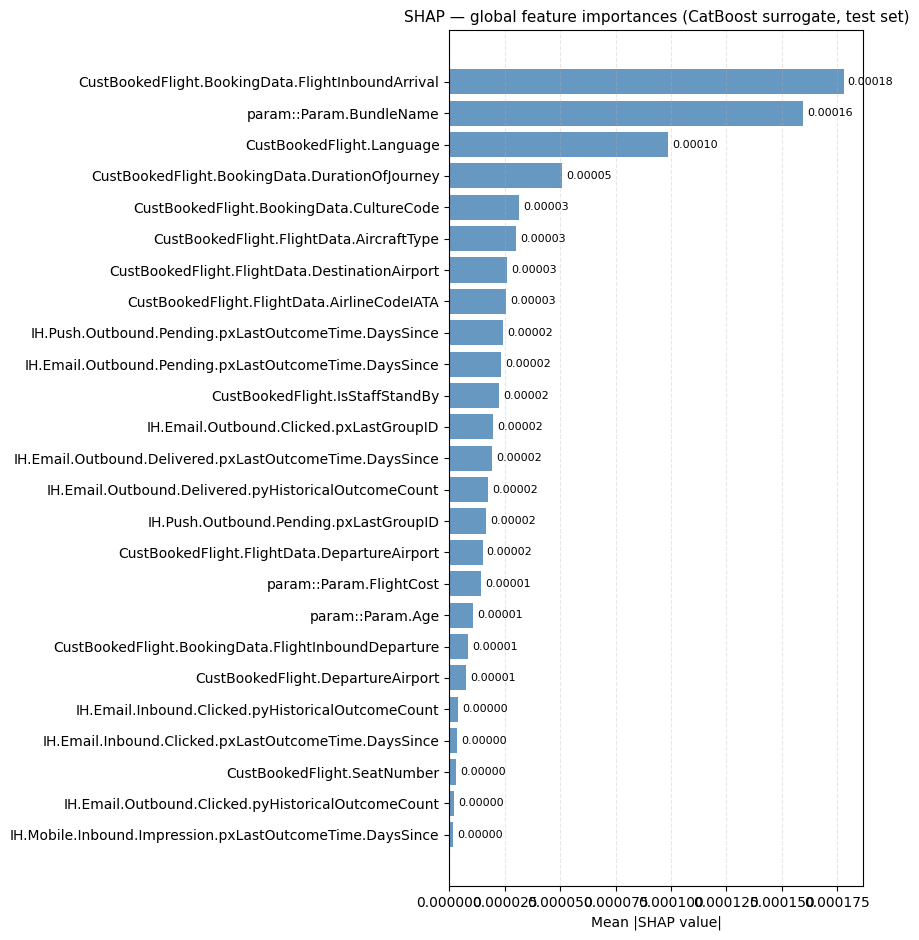

In [10]:
### 10.2  SHAP global bar chart
fig, ax = plt.subplots(figsize=(9, max(4, len(shap_mean_abs) * 0.38)))
bars = ax.barh(shap_mean_abs.index[::-1], shap_mean_abs.values[::-1], color="steelblue", alpha=0.82)
ax.bar_label(bars, fmt="%.5f", padding=3, fontsize=8)
ax.set_xlabel("Mean |SHAP value|")
ax.set_title("SHAP — global feature importances (CatBoost surrogate, test set)", fontsize=11)
ax.grid(axis="x", alpha=0.3, linestyle="--")
plt.tight_layout()
plt.show()

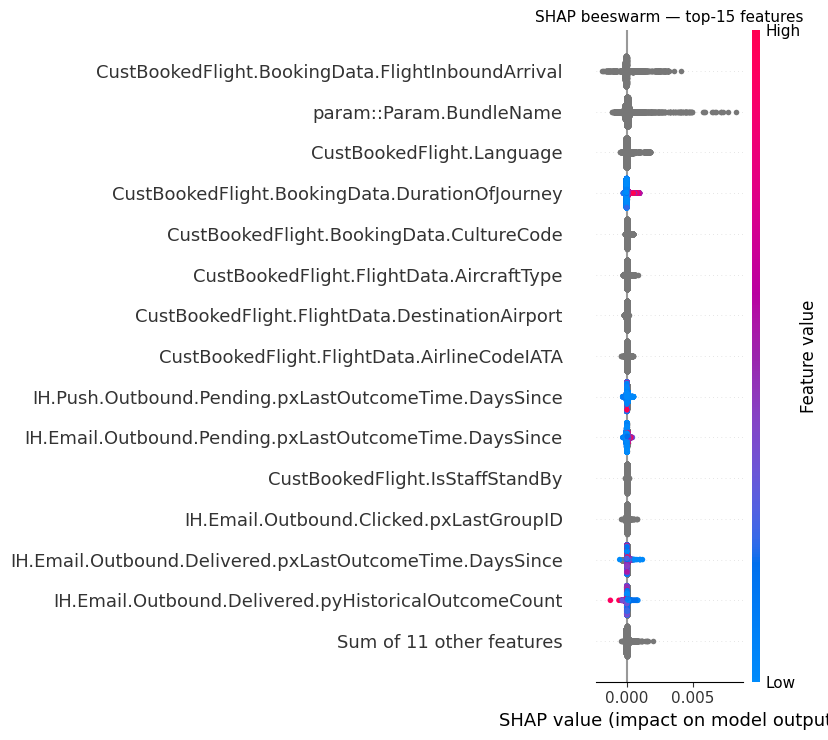

In [11]:
### 10.3  SHAP beeswarm (value direction)
shap_exp = shap.Explanation(
    values=shap_vals,
    base_values=np.full(len(X_test), shap.TreeExplainer(cb_model).expected_value),
    data=X_test.values,
    feature_names=list(X_test.columns),
)
shap.plots.beeswarm(shap_exp, max_display=15, show=False)
plt.title("SHAP beeswarm — top-15 features", fontsize=11)
plt.tight_layout()
plt.show()

## 11. LIME

LIME (Local Interpretable Model-agnostic Explanations) fits a local linear model around each instance.  
We run it on the full test set and aggregate mean |coefficient| as the global importance estimate.  
This is slower than SHAP (~minutes for 454 instances × 500 perturbations each).

In [12]:
### 11.1  Run LIME on test set
# n_samples=500 balances stability vs runtime (~1–2 min for 12,802 instances).
lime_df = lime_explain_batch(
    cb_model, X_train, X_test, cat_cols, num_cols,
    n_samples=500, n_features=len(X_test.columns),
)
print(f"LIME explanations: {len(lime_df):,} rows  ({lime_df['instance_idx'].nunique()} instances)")
lime_df.head()

LIME explanations: 210,800 rows  (8432 instances)


,instance_idx,feature,importance
0,0,IH.Email.Outbound.Clicked.pyHistoricalOutcomeC...,-0.000283
1,0,CustBookedFlight.Language=6,-0.000128
2,0,IH.Push.Outbound.Pending.pxLastOutcomeTime.Day...,-0.000119
3,0,CustBookedFlight.DepartureAirport=18,-0.000099
4,0,IH.Push.Outbound.Pending.pxLastGroupID=2,-0.000086


In [13]:
### 11.2  Aggregate LIME importances
# LIME feature labels include the split condition (e.g., "SeatNumber <= 0.50").
# We map each label back to its base feature name for cross-method comparison.
feature_names = list(X_test.columns)

def _strip_lime_condition(label: str, feature_names: list[str]) -> str:
    """Extract the base feature name from a LIME condition string."""
    for fn in sorted(feature_names, key=len, reverse=True):  # longest match first
        if fn in label:
            return fn
    return label  # fallback: return as-is

lime_df["base_feature"] = lime_df["feature"].apply(
    lambda lbl: _strip_lime_condition(lbl, feature_names)
)

lime_global = (
    lime_df.assign(abs_importance=lambda d: d["importance"].abs())
    .groupby("base_feature")["abs_importance"]
    .mean()
    .sort_values(ascending=False)
    .rename("mean_abs_lime")
)
lime_ranks = feature_ranking(lime_global)

display(
    pd.DataFrame({"mean_abs_lime": lime_global, "rank": lime_ranks})
    .head(15)
    .style.format({"mean_abs_lime": "{:.5f}", "rank": "{:d}"})
)

,mean_abs_lime,rank
base_feature,,
IH.Email.Inbound.Clicked.pyHistoricalOutcomeCount,0.00018,1
CustBookedFlight.BookingData.FlightInboundArrival,0.00014,2
CustBookedFlight.Language,0.00013,3
CustBookedFlight.FlightData.DestinationAirport,0.00009,4
param::Param.BundleName,0.00009,5
CustBookedFlight.BookingData.FlightInboundDeparture,0.00008,6
param::Param.Age,0.00007,7
CustBookedFlight.BookingData.DurationOfJourney,0.00007,8
IH.Email.Inbound.Clicked.pxLastOutcomeTime.DaysSince,0.00007,9


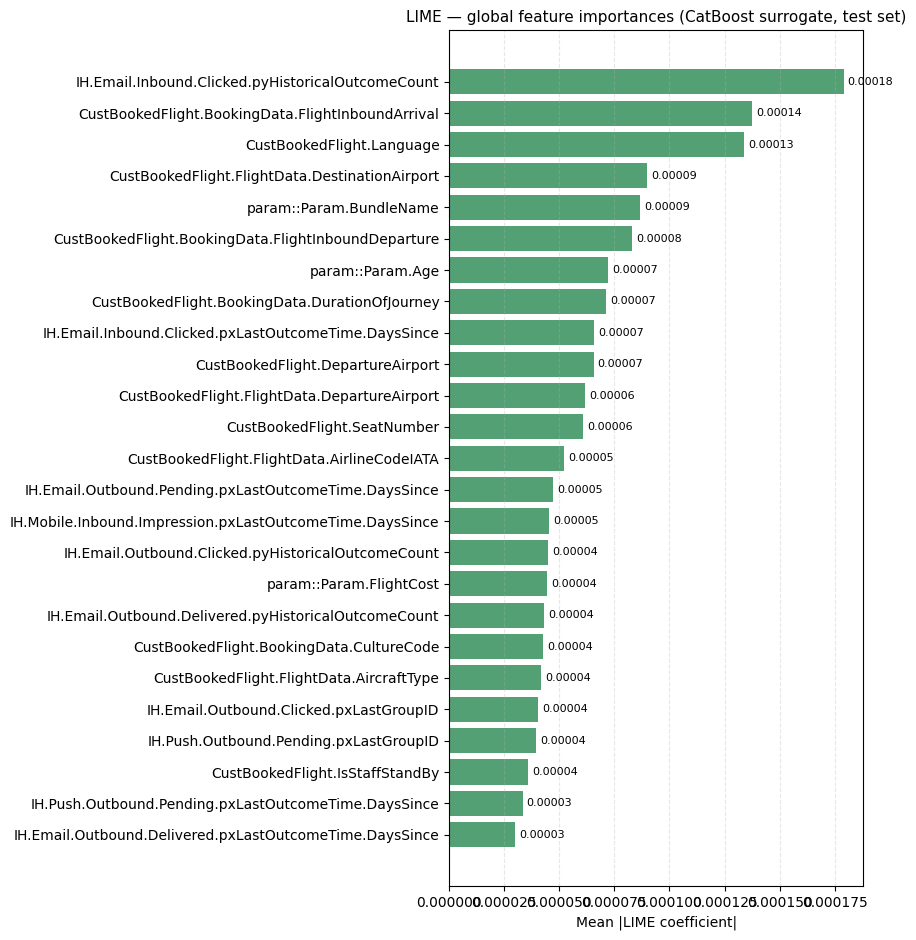

In [14]:
### 11.3  LIME global bar chart
fig, ax = plt.subplots(figsize=(9, max(4, len(lime_global) * 0.38)))
bars = ax.barh(lime_global.index[::-1], lime_global.values[::-1], color="seagreen", alpha=0.82)
ax.bar_label(bars, fmt="%.5f", padding=3, fontsize=8)
ax.set_xlabel("Mean |LIME coefficient|")
ax.set_title("LIME — global feature importances (CatBoost surrogate, test set)", fontsize=11)
ax.grid(axis="x", alpha=0.3, linestyle="--")
plt.tight_layout()
plt.show()

## 12. Cross-method comparison

Rank correlation (Spearman ρ) and Jaccard@5/10 between the three feature ranking vectors.  
High agreement supports robustness; divergence highlights where explainer-specific assumptions matter.

In [15]:
### 12.1  Align rankings to shared feature index
shared_features = list(X_test.columns)

# Reindex all importance series to shared_features, fill missing with 0
imp_dt   = dt_imp.reindex(shared_features).fillna(0)
imp_shap = shap_mean_abs.reindex(shared_features).fillna(0)
imp_lime = lime_global.reindex(shared_features).fillna(0)

rank_dt   = feature_ranking(imp_dt)
rank_shap = feature_ranking(imp_shap)
rank_lime = feature_ranking(imp_lime)

pairs = [
    ("DT",   "SHAP", rank_dt,   rank_shap),
    ("DT",   "LIME", rank_dt,   rank_lime),
    ("SHAP", "LIME", rank_shap, rank_lime),
]

rows = []
for m1, m2, r1, r2 in pairs:
    rows.append({
        "pair":      f"{m1} vs {m2}",
        "Spearman ρ": round(stability_spearman(r1, r2), 4),
        "Jaccard@5":  round(jaccard_at_k(r1, r2, k=5),  4),
        "Jaccard@10": round(jaccard_at_k(r1, r2, k=10), 4),
    })

comparison_df = pd.DataFrame(rows).set_index("pair")
display(
    comparison_df.style
    .format("{:.4f}")
    .highlight_max(color="#d4edda")
    .highlight_min(color="#f8d7da")
)

,Spearman ρ,Jaccard@5,Jaccard@10
pair,,,
DT vs SHAP,-0.2074,0.1111,0.1765
DT vs LIME,-0.4131,0.0000,0.1111
SHAP vs LIME,0.0785,0.4286,0.3333


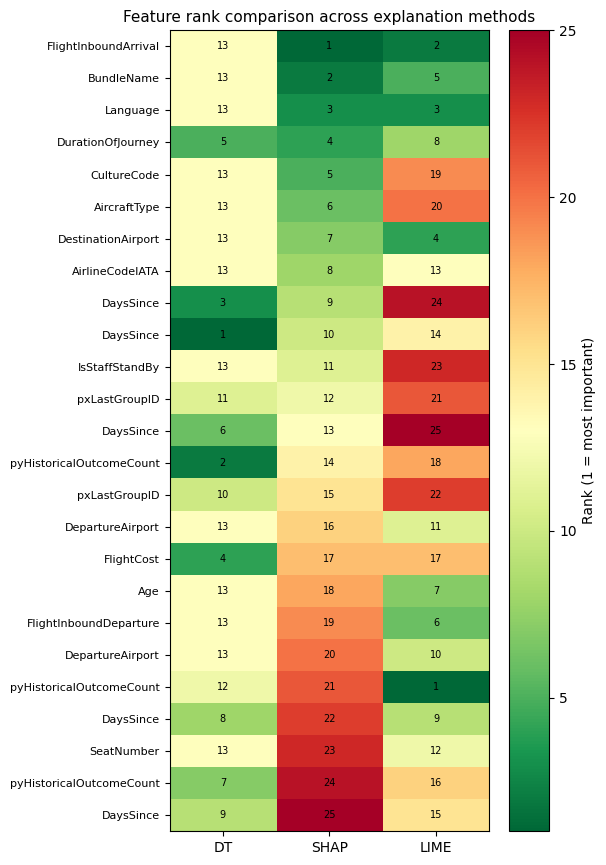

In [16]:
### 12.2  Rank comparison heatmap
rank_matrix = pd.DataFrame({
    "DT":   rank_dt,
    "SHAP": rank_shap,
    "LIME": rank_lime,
}).sort_values("SHAP")  # sort rows by SHAP rank for readability

# Short feature names for display
short_index = [col.split(".")[-1] for col in rank_matrix.index]

fig, ax = plt.subplots(figsize=(6, max(5, len(rank_matrix) * 0.35)))
im = ax.imshow(rank_matrix.values, aspect="auto", cmap="RdYlGn_r")
ax.set_xticks(range(3))
ax.set_xticklabels(["DT", "SHAP", "LIME"], fontsize=10)
ax.set_yticks(range(len(short_index)))
ax.set_yticklabels(short_index, fontsize=8)

for i in range(len(rank_matrix)):
    for j, col in enumerate(["DT", "SHAP", "LIME"]):
        ax.text(j, i, str(int(rank_matrix.iloc[i, j])), ha="center", va="center", fontsize=7)

plt.colorbar(im, ax=ax, label="Rank (1 = most important)")
ax.set_title("Feature rank comparison across explanation methods", fontsize=11)
plt.tight_layout()
plt.show()

In [17]:
### 12.3  Save explanation artifacts
import pickle

# Decision tree
with open(ARTIFACT_DIR / "dt_model.pkl", "wb") as f:
    pickle.dump({"tree": dt, "encoder": dt_encoder, "best_depth": best_depth}, f)

# SHAP values
np.save(ARTIFACT_DIR / "shap_values.npy", shap_vals)
(ARTIFACT_DIR / "shap_importances.json").write_text(
    shap_mean_abs.to_json(), encoding="utf-8"
)

# LIME
lime_df.to_parquet(ARTIFACT_DIR / "lime_explanations.parquet", index=False)
(ARTIFACT_DIR / "lime_importances.json").write_text(
    lime_global.to_json(), encoding="utf-8"
)

# Cross-method comparison
(ARTIFACT_DIR / "cross_method_comparison.json").write_text(
    comparison_df.to_json(orient="index"), encoding="utf-8"
)

print("Artifacts saved:")
for f in sorted(ARTIFACT_DIR.iterdir()):
    print(f"  {f.name}")

Artifacts saved:
  cat_cols.json
  catboost_model.cbm
  cross_method_comparison.json
  dt_model.pkl
  dt_rules.txt
  feature_cols.json
  fidelity.json
  lime_explanations.parquet
  lime_importances.json
  num_cols.json
  shap_importances.json
  shap_values.npy
  test_idx.npy
  train_idx.npy
